In [51]:
import pytest
import requests

BASE = 'http://localhost:8000/api'

@pytest.mark.smoke
class TestBibliotecaSmoke:

    def test_01_api_disponible(self):
        respuesta = requests.get(f"{BASE}/health")
        assert respuesta.status_code == 200
        assert respuesta.json()['status'] == 'ok'

    def test_02_login_funciona(self):
        respuesta = requests.post(f"{BASE}/auth/login", json={
            "email": "test@unicolombia.edu.co",
            "password": "Test123!"
        })
        assert respuesta.status_code == 200
        assert 'access_token' in respuesta.json()

    def test_03_listar_libros_responde(self):
        respuesta = requests.get(f"{BASE}/libros")
        assert respuesta.status_code in [200, 401]

    def test_04_base_de_datos_conectada(self):
        respuesta = requests.get(f"{BASE}/health")
        assert respuesta.status_code == 200
        assert respuesta.json()['db'] == 'connected'

    def test_05_modulo_multas_responde(self):
        respuesta = requests.get(f"{BASE}/multas/2024-001")
        assert respuesta.status_code != 404, "El módulo de multas no fue desplegado"
        assert respuesta.status_code != 500, "El módulo de multas tiene un error interno"

1.2 Preguntas de análisis
1. ¿Por qué es importante que los smoke tests fallen rápido (fail-fast)?

Porque si el sistema ni siquiera está activo o tiene un error fundamental, no tiene sentido ejecutar cientos de
tests de regresión o aceptación que tardarían horas. El principio fail-fast ahorra tiempo al equipo: si el smoke
test test_01_api_disponible falla, sabes en segundos que el build está roto y puedes notificar al equipo
sin esperar más. Además, evita generar reportes de falsos errores causados por el problema raíz.

2. ¿Qué harías si el smoke test test_01_api_disponible falla? ¿Ejecutarías los demás?

No ejecutaría los demás. Si la API no responde, todos los tests siguientes fallarán por la misma causa (el
servidor no está activo), generando ruido en el reporte. La acción correcta es detener el pipeline
inmediatamente, registrar el fallo como "build rechazado" y notificar al equipo de desarrollo para que corrijan
el despliegue antes de continuar con cualquier otra prueba.

In [52]:

import os
os.makedirs("tests/regression", exist_ok=True)
os.makedirs("tests/smoke", exist_ok=True)

In [53]:

%%writefile tests/__init__.py

Overwriting tests/__init__.py


In [54]:
%%writefile tests/regression/__init__.py

Overwriting tests/regression/__init__.py


In [55]:

%%writefile tests/regression/test_prestamos_regression.py
import pytest
import datetime
from biblioteca.prestamos import calcular_disponibilidad
from biblioteca.prestamos import registrar_prestamo, registrar_devolucion
from biblioteca.multas import calcular_multa

TARIFA_DIARIA = 1500

@pytest.mark.regression
class TestPrestamosRegression:

    def test_libro_prestado_no_esta_disponible(self):
        libro_id = 101
        estudiante = "2024-001"
        fecha_prestamo = datetime.date.today()
        fecha_limite = fecha_prestamo + datetime.timedelta(days=14)
        registrar_prestamo(libro_id, estudiante, fecha_prestamo, fecha_limite)
        disponible = calcular_disponibilidad(libro_id)
        assert disponible == False, (
            "Un libro prestado no puede aparecer como disponible. "
            "Verificar que el merge no rompió calcular_disponibilidad()."
        )

    def test_libro_disponible_tras_devolucion(self):
        libro_id = 102
        estudiante = "2024-002"
        fecha_prestamo = datetime.date.today() - datetime.timedelta(days=5)
        fecha_limite = fecha_prestamo + datetime.timedelta(days=14)
        prestamo = registrar_prestamo(libro_id, estudiante, fecha_prestamo, fecha_limite)
        registrar_devolucion(prestamo['prestamo_id'], datetime.date.today())
        disponible = calcular_disponibilidad(libro_id)
        assert disponible == True, (
            "Después de la devolución, el libro debe quedar disponible."
        )

    def test_bug_2024_031_no_disponible_con_prestamo_antiguo(self):
        libro_id = 103
        estudiante = "2024-003"
        fecha_prestamo = datetime.date.today() - datetime.timedelta(days=45)
        fecha_limite = fecha_prestamo + datetime.timedelta(days=14)
        registrar_prestamo(libro_id, estudiante, fecha_prestamo, fecha_limite)
        disponible = calcular_disponibilidad(libro_id)
        assert disponible == False, (
            "BUG-2024-031 REGRESÓ: Un préstamo antiguo (45 días) "
            "no debe considerarse devuelto automáticamente."
        )

    def test_multa_no_afecta_disponibilidad_de_otro_libro(self):
        libro_libre_id = 200
        disponible = calcular_disponibilidad(libro_libre_id)
        assert disponible == True, (
            "Una multa de un estudiante no debe afectar la disponibilidad "
            "de libros que no están prestados a ese estudiante."
        )

    def test_calculo_multa_tres_dias_retraso(self):
        dias_retraso = 3
        multa_esperada = dias_retraso * TARIFA_DIARIA
        multa_calculada = calcular_multa(dias_retraso)
        assert multa_calculada == multa_esperada, (
            f"3 días de retraso deben generar ${multa_esperada} COP, "
            f"pero se calcularon ${multa_calculada} COP."
        )

Overwriting tests/regression/test_prestamos_regression.py


In [56]:

import os
print(os.listdir('tests/regression'))
print(os.listdir('biblioteca'))

['test_prestamos_regression.py', '__pycache__', '__init__.py']
['__pycache__', 'multas.py', '__init__.py', 'prestamos.py']


In [57]:

%%writefile pytest.ini
[pytest]
markers =
    regression: Tests de regresión para verificar que bugs corregidos no regresen
    smoke: Tests rápidos para verificar que el sistema básico funciona
!pytest tests/regression/test_prestamos_regression.py -v

Overwriting pytest.ini


2.2 Preguntas de análisis

3. ¿Por qué se incluyó test_bug_2024_031? ¿Qué tipo de regresión previene?

Se incluyó porque ese bug ya ocurrió una vez en producción: el sistema marcaba como disponible un libro
que en realidad seguía prestado si el préstamo tenía más de 30 días. Al hacer el merge de
feature/multas, la función calcular_disponibilidad() fue modificada y existe el riesgo de que ese
comportamiento incorrecto reaparezca. Este test previene una regresión de bug histórico: garantiza que
una falla ya corregida no vuelva a introducirse con futuros cambios de código.

4. ¿Qué tipo de regression testing (completa, parcial, selectiva) usarías para este merge y por qué?

Usaría regression testing selectiva. El merge solo modificó calcular_disponibilidad() y el módulo
de multas, por lo que no es necesario ejecutar todos los tests del sistema (eso tomaría horas). Con análisis
de impacto identificamos que los módulos afectados son préstamos, disponibilidad y multas, y enfocamos los
tests en esas áreas. Esto es más eficiente que la p

In [58]:

import os
os.makedirs("features", exist_ok=True)

In [59]:
%%writefile features/multas.feature
Feature: Sistema de multas por devolución tardía
  Como estudiante de la Universitaria de Colombia
  Quiero conocer y gestionar mis multas de biblioteca
  Para poder planificar mis reservas de libros

  # AC-1: Cálculo correcto de la multa
  Scenario: Cálculo de multa por 3 días de retraso
    Given que el estudiante "Carlos Pérez" devolvió el libro "Clean Code"
    And la fecha límite de devolución fue hace 3 días
    When el sistema calcula la multa pendiente
    Then la multa debe ser de $1500 COP
    And el desglose debe mostrar "3 días × $500 = $1500"

  # AC-2: Mensaje cuando no hay multa
  Scenario: Estudiante sin multa pendiente
    Given que el estudiante "Ana García" devolvió todos sus libros a tiempo
    When el estudiante consulta su estado de multas
    Then el sistema debe mostrar el mensaje "Sin multa pendiente"
    And la multa total debe ser $0 COP

  # AC-3: Bloqueo por multa pendiente
  Scenario: Estudiante con multa no puede reservar
    Given que el estudiante "Luis Torres" tiene una multa pendiente de $2000 COP
    And el libro "Refactoring" está disponible en la biblioteca
    When Luis Torres intenta reservar el libro "Refactoring"
    Then el sistema debe rechazar la reserva
    And debe mostrar el mensaje "Tienes una multa pendiente de $2000 COP. Págala para hacer nuevas reservas"

Overwriting features/multas.feature


3.2 Plan UAT — Completa la tabla

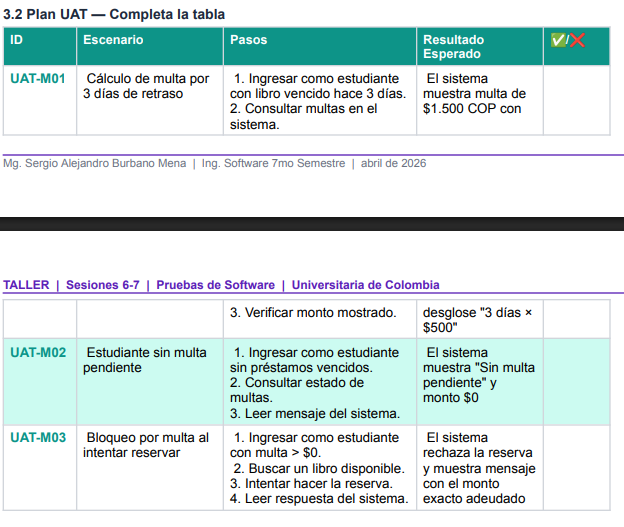

3.3 Reflexión final

5. ¿Cuál es la diferencia principal entre que QA apruebe las pruebas y que el cliente/PO las apruebe?

QA verifica que el sistema funciona correctamente desde el punto de vista técnico: que el código no tiene
errores, que los valores calculados son exactos, que no hay excepciones. El cliente o Product Owner verifica
que el sistema hace lo que ellos necesitan desde el punto de vista del negocio: que el mensaje que ve el
estudiante es comprensible, que el flujo de pago tiene sentido, que las reglas de multa coinciden con la
política real de la biblioteca. Un sistema puede pasar todos los tests de QA y aún así no satisfacer al cliente
si, por ejemplo, el mensaje de bloqueo es confuso o la tarifa diaria no fue la acordada.

6. Si el taller de hoy fuera un proyecto real, ¿en qué orden ejecutarías los 3 tipos de prueba y por qué?

El orden correcto es Smoke → Regression → Acceptance. Primero el Smoke Testing porque verifica en
minutos si el sistema siquiera está activo; si falla, los otros dos no tienen sentido. Luego el Regression
Testing para garantizar que el merge no rompió funcionalidades que ya estaban validadas; esto se hace
antes de involucrar al cliente para no hacerle perder tiempo. Finalmente el Acceptance Testing con el Product
Owner, cuando ya se sabe que el sistema está estable y que nada antiguo se rompió, así la reunión de
validación se enfoca solo en si el nuevo comportamiento cumple los criterios de negocio.
